<a href="https://colab.research.google.com/github/HARISHRAJ-R-07/Data-Scientist-DS-Module---4-Assignment-6-Linear-Regression/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Data Scientist (DS)** **Module - 4**

##**Assignment 6: Linear Regression**


###**Assignment Task Overview:**
####**Problem Statement - Mobile Price Prediction using Linear Regression**

Mobile prices are influenced by various factors such as the amount of RAM, the quality of the
camera, battery power, screen resolution (PPI) and other hardware specifications. Your goal is to
analyze these factors, build a Linear Regression model, and use it to make accurate predictions of
mobile phone prices based on the dataset provided.



###**1. Explore the Dataset:**

* Analyze the mobile price dataset to understand its structure, feature distributions, and
relationships before model building.

In [ ]:
# Explore the dataset:

import numpy as np
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/ArchanaInsights/Datasets/main/mobile_price.csv")
df

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
0,203,2357,10,135.0,5.20,424,8,1.350,16.0,3.000,13.00,8.0,2610,7.4
1,880,1749,10,125.0,4.00,233,2,1.300,4.0,1.000,3.15,0.0,1700,9.9
2,40,1916,10,110.0,4.70,312,4,1.200,8.0,1.500,13.00,5.0,2000,7.6
3,99,1315,11,118.5,4.00,233,2,1.300,4.0,0.512,3.15,0.0,1400,11.0
4,880,1749,11,125.0,4.00,233,2,1.300,4.0,1.000,3.15,0.0,1700,9.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,1206,3551,4638,178.0,5.46,538,4,1.875,128.0,6.000,12.00,16.0,4080,8.4
157,1296,3211,8016,170.0,5.50,534,4,1.975,128.0,6.000,20.00,8.0,3400,7.9
158,856,3260,8809,150.0,5.50,401,8,2.200,64.0,4.000,20.00,20.0,3000,6.8
159,1296,3211,8946,170.0,5.50,534,4,1.975,128.0,6.000,20.00,8.0,3400,7.9


### **Perform the steps:**

* Inspect dataset shape, columns, data types, and missing values
* Generate statistical summaries for numerical features
* Create a correlation heatmap focusing on Price
* Identify the top 4 features most correlated with Price
* Plot scatter plots for these features against Price and analyze the relationships

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product_id    161 non-null    int64  
 1   Price         161 non-null    int64  
 2   Sale          161 non-null    int64  
 3   weight        161 non-null    float64
 4   resoloution   161 non-null    float64
 5   ppi           161 non-null    int64  
 6   cpu core      161 non-null    int64  
 7   cpu freq      161 non-null    float64
 8   internal mem  161 non-null    float64
 9   ram           161 non-null    float64
 10  RearCam       161 non-null    float64
 11  Front_Cam     161 non-null    float64
 12  battery       161 non-null    int64  
 13  thickness     161 non-null    float64
dtypes: float64(8), int64(6)
memory usage: 17.7 KB


In [ ]:
#  Inspect dataset shape, columns, data types, and missing values

print("Shape of data :\n",df.shape)
print("Columns :\n",df.columns)
print("Datatypes in data :\n",df.dtypes)
print("Missing values :\n",df.isnull().sum())

Shape of data :
 (161, 14)
Columns :
 Index(['Product_id', 'Price', 'Sale', 'weight', 'resoloution', 'ppi',
       'cpu core', 'cpu freq', 'internal mem', 'ram', 'RearCam', 'Front_Cam',
       'battery', 'thickness'],
      dtype='object')
Datatypes in data :
 Product_id        int64
Price             int64
Sale              int64
weight          float64
resoloution     float64
ppi               int64
cpu core          int64
cpu freq        float64
internal mem    float64
ram             float64
RearCam         float64
Front_Cam       float64
battery           int64
thickness       float64
dtype: object
Missing values :
 Product_id      0
Price           0
Sale            0
weight          0
resoloution     0
ppi             0
cpu core        0
cpu freq        0
internal mem    0
ram             0
RearCam         0
Front_Cam       0
battery         0
thickness       0
dtype: int64


In [ ]:
# Generate statistical summaries for numerical features

df.describe()

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
count,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000
mean,675.559006,2215.596273,621.465839,170.426087,5.209938,335.055901,4.857143,1.502832,24.501714,2.204994,10.378261,4.503106,2842.111801,8.921739
std,410.851583,768.187171,1546.618517,92.888612,1.509953,134.826659,2.444016,0.599783,28.804773,1.609831,6.181585,4.342053,1366.990838,2.192564
min,10.000000,614.000000,10.000000,66.000000,1.400000,121.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,800.000000,5.100000
25%,237.000000,1734.000000,37.000000,134.100000,4.800000,233.000000,4.000000,1.200000,8.000000,1.000000,5.000000,0.000000,2040.000000,7.600000
50%,774.000000,2258.000000,106.000000,153.000000,5.150000,294.000000,4.000000,1.400000,16.000000,2.000000,12.000000,5.000000,2800.000000,8.400000
75%,1026.000000,2744.000000,382.000000,170.000000,5.500000,428.000000,8.000000,1.875000,32.000000,3.000000,16.000000,8.000000,3240.000000,9.800000
max,1339.000000,4361.000000,9807.000000,753.000000,12.200000,806.000000,8.000000,2.700000,128.000000,6.000000,23.000000,20.000000,9500.000000,18.500000


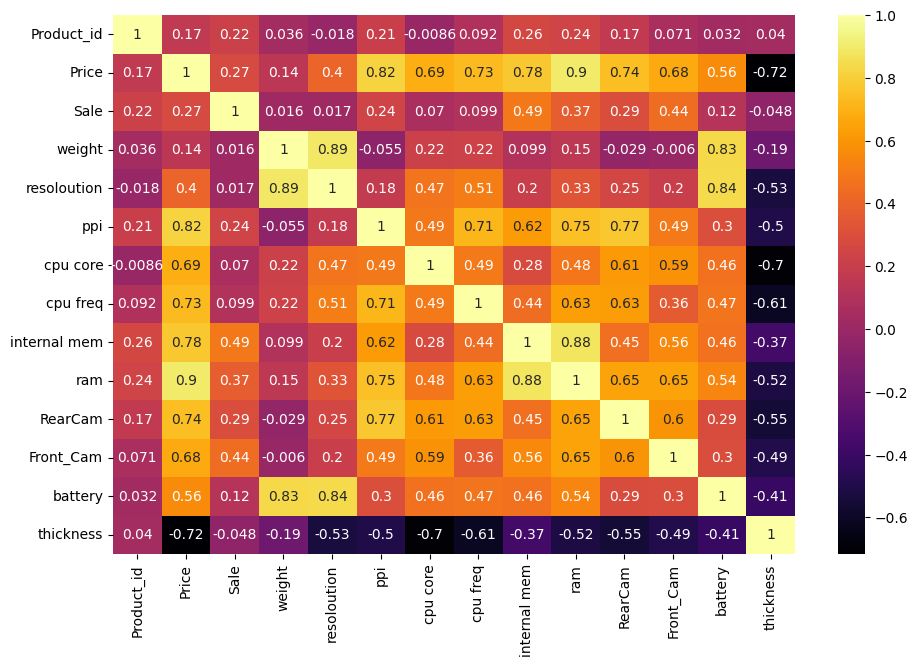

In [ ]:
# Create a correlation heatmap focusing on Price

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(11,7))
sns.heatmap(df.corr(), cmap='inferno', annot=True)
plt.show()

In [ ]:
df[['ram','battery','Front_Cam','cpu core']]

,ram,battery,Front_Cam,cpu core
0,3.000,2610,8.0,8
1,1.000,1700,0.0,2
2,1.500,2000,5.0,4
3,0.512,1400,0.0,2
4,1.000,1700,0.0,2
...,...,...,...,...
156,6.000,4080,16.0,4
157,6.000,3400,8.0,4
158,4.000,3000,20.0,8
159,6.000,3400,8.0,4


In [ ]:
# Identify the top 4 features most correlated with Price

from IPython.display import display

display(df[['ram','battery','Front_Cam','cpu core']])
display(df['Price'])

,ram,battery,Front_Cam,cpu core
0,3.000,2610,8.0,8
1,1.000,1700,0.0,2
2,1.500,2000,5.0,4
3,0.512,1400,0.0,2
4,1.000,1700,0.0,2
...,...,...,...,...
156,6.000,4080,16.0,4
157,6.000,3400,8.0,4
158,4.000,3000,20.0,8
159,6.000,3400,8.0,4


,Price
0,2357
1,1749
2,1916
3,1315
4,1749
...,...
156,3551
157,3211
158,3260
159,3211


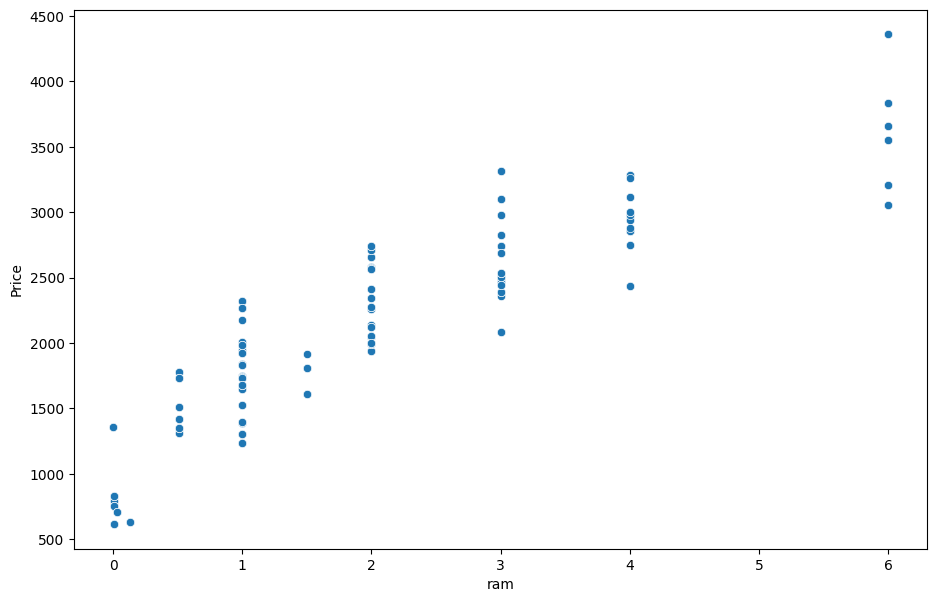

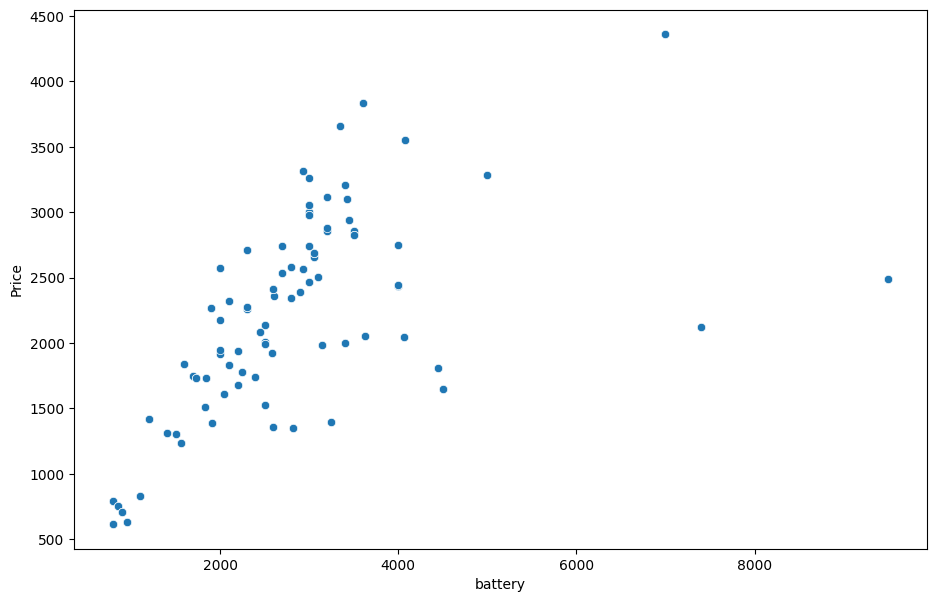

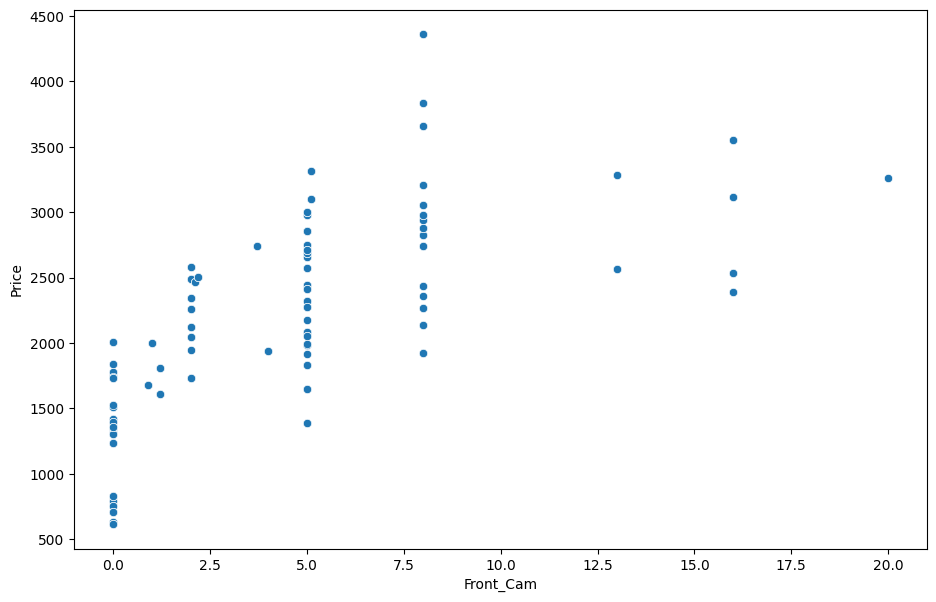

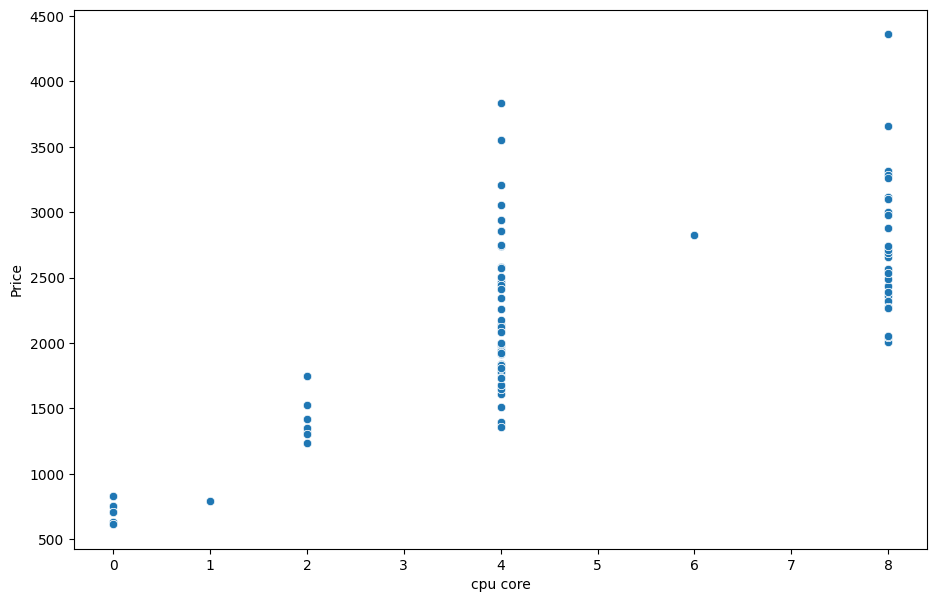

In [ ]:
# Plot scatter plots for these features (ram,battery,Front_Cam,cpu core) against Price and analyze the relationships

plt.figure(figsize=(11,7))
sns.scatterplot(x='ram',y='Price',data=df)
plt.show()

plt.figure(figsize=(11,7))
sns.scatterplot(x='battery',y='Price',data=df)
plt.show()

plt.figure(figsize=(11,7))
sns.scatterplot(x='Front_Cam',y='Price',data=df)
plt.show()

plt.figure(figsize=(11,7))
sns.scatterplot(x='cpu core',y='Price',data=df)
plt.show()

###**2. Prepare the Data:**
* **Feature Selection:** Select the features and the target variable for your analysis.

* **Split the Dataset:** Divide the dataset into training and testing sets. Use 80% of the data for
training and 20% for testing.

In [ ]:
# Feature Selection: Select the features and the target variable for your analysis
x = df[['ram','battery','Front_Cam','cpu core']]
display(x)
y = df['Price']
display(y)

,ram,battery,Front_Cam,cpu core
0,3.000,2610,8.0,8
1,1.000,1700,0.0,2
2,1.500,2000,5.0,4
3,0.512,1400,0.0,2
4,1.000,1700,0.0,2
...,...,...,...,...
156,6.000,4080,16.0,4
157,6.000,3400,8.0,4
158,4.000,3000,20.0,8
159,6.000,3400,8.0,4


,Price
0,2357
1,1749
2,1916
3,1315
4,1749
...,...
156,3551
157,3211
158,3260
159,3211


In [ ]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x, y, test_size=0.20, random_state=45)

In [ ]:
# Split the Dataset: Divide the dataset into training and testing sets. Use 80% of the data for training and 20% for testing.

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(128, 4)
(33, 4)
(128,)
(33,)


###**3. Build and Train the Model:**
* **Create a Linear Regression Model:** Build a linear regression model using the training data.
* **Train the Model:** Fit the model to the training data.

In [ ]:
# Create a Linear Regression Model: Build a linear regression model using the training data.

from sklearn.linear_model import LinearRegression

# Train the Model: Fit the model to the training data.

lr_model = LinearRegression()
lr_model.fit(x_train, y_train)

LinearRegression()

In [ ]:
display(x_train)
display(y_train)

,ram,battery,Front_Cam,cpu core
106,2.0,2700,8.0,8
69,1.0,2100,5.0,8
100,2.0,2800,2.0,4
144,1.0,2580,8.0,4
117,4.0,5000,13.0,8
...,...,...,...,...
95,1.5,4450,1.2,4
32,3.0,2930,5.1,8
124,4.0,3200,8.0,8
131,0.0,2600,0.0,4


,Price
106,2744
69,2323
100,2343
144,1921
117,3287
...,...
95,1810
32,3316
124,2880
131,1357


###**4. Evaluate the Model:**
* **Predict:** Use the model to make predictions on the test set.
* **Metrics Calculation:** Evaluate the model’s performance using the following metrics

**❖ Slope (Coefficient) and Intercept:** Print the slope (coefficient) and intercept of the
regression line.

**❖ Model Performance Metrics:** Calculate and report the following metrics:

**❖ R2 Score:** How well does the model explain the variance in the target variable?

**❖ Mean Absolute Error (MAE):** What is the average absolute difference between predicted
and actual values?

**❖ Mean Squared Error (MSE):** What is the average of the squared differences between
predicted and actual values?

In [ ]:
# Predict: Use the model to make predictions on the test set.

y_pred = lr_model.predict(x_test)
y_pred

array([1533.74369604, 2826.32458932, 2500.01022523, 1527.70455388,
       2765.60234422, 1307.83377967, 2765.60234422, 2129.08488496,
       3171.26802863, 2487.01986232, 2757.05527971, 3178.96156182,
       3192.63686503,  912.18126587, 2134.3448027 , 1717.94907927,
        918.67971032, 2935.55372342, 2836.20955797,  957.22176334,
       2829.5712987 , 2046.31121344, 3929.02212482, 1493.80242254,
       1702.1358348 , 2751.92704101, 1699.48506967, 1746.49509958,
       2401.82456169, 1304.41495387, 3190.36078152, 1480.12711933,
       2423.05090784])

In [ ]:
# Metrics Calculation:

from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

print(f'Intercept={lr_model.intercept_}')
print(f'Coefficient(Slope)={lr_model.coef_}')
print(f'Mean Squared Error ={mean_squared_error(y_test,y_pred)}')
print(f'Mean absolute Error ={mean_absolute_error(y_test,y_pred)}')
print(f'R2_score ={r2_score(y_test,y_pred)}')


Intercept=897.1357569201821
Coefficient(Slope)=[3.42551436e+02 1.70941290e-02 1.42490246e+00 1.05689953e+02]
Mean Squared Error =77263.12461876028
Mean absolute Error =216.0116403243195
R2_score =0.8738664582639157


In [ ]:
# Get the slope (coefficient) for each feature

ram_slope = lr_model.coef_[0]
battery_slope = lr_model.coef_[1]
front_cam_slope = lr_model.coef_[2]
cpu_core_slope = lr_model.coef_[3]

print("RAM Slope:", ram_slope)
print("Battery Slope:", battery_slope)
print("Front Camera Slope:", front_cam_slope)
print("CPU Core Slope:", cpu_core_slope)

RAM Slope: 342.5514363822991
Battery Slope: 0.0170941290093429
Front Camera Slope: 1.42490246241256
CPU Core Slope: 105.68995335521392


# **5. Conclusion of the Analysis**

## **Model Evaluation**

The Linear Regression model gives a good prediction of mobile prices. The model achieved an **R² score of 0.8739**, which means that the model explains about **87.39% of the variation in mobile prices**.

The **Mean Absolute Error (MAE) is 216.01**, which means that the predicted price is different from the actual price by about 216 units on average.

The **Mean Squared Error (MSE) is 77263.12**. Overall, the model gives satisfactory results, but there is still some difference between the predicted and actual prices. The model can be improved by using more useful features and better data preprocessing.

## **Insights and Discussion**

### **❖ Correlation Analysis and Scatter Plots**

From the correlation analysis and scatter plots, I found that **RAM, battery, Front Camera, and CPU cores** have a relationship with mobile price. These features were selected as the top features for building the Linear Regression model. The scatter plots also helped to understand how these features are related to mobile prices.

### **❖ Contribution of Selected Features**

The selected features contribute to predicting mobile prices in different ways.

* **RAM** has a positive contribution to the mobile price.
* **Battery** also contributes to the prediction of price.
* **Front Camera** has a smaller contribution compared with the other features.
* **CPU cores** have a positive contribution to the price.

Using these four features together helps the model predict mobile prices better.

### **❖ Slope (Coefficient) and Intercept**

The model intercept is **897.14**. The coefficients are:

* **RAM:** 342.55
* **Battery:** 0.017
* **Front Camera:** 1.42
* **CPU Core:** 105.69

The positive coefficients show that an increase in these features is associated with an increase in the predicted mobile price, while keeping the other features constant.

The slope tells us how much the predicted price changes when a feature increases by one unit. The intercept represents the estimated price when all selected feature values are zero.

### **❖ Model Performance and Difference Between Actual and Predicted Values**

The model achieved an **R² score of 0.8739**, which shows that the model performs well on the test data. The **MAE of 216.01** shows that there is an average difference of about 216 between the actual and predicted prices.

There are some differences between the actual and predicted values because a Linear Regression model cannot capture every factor that affects mobile prices.

### **❖ Potential Improvements**

The model performance can be improved by:

* Using more relevant features from the dataset.
* Handling outliers properly.
* Checking and improving the quality of the data.
* Trying feature scaling if required.
* Testing other machine learning models such as **Decision Tree, Random Forest, or Gradient Boosting**.
* Using cross-validation to check the model performance more reliably.

## **Overall Conclusion**

The Linear Regression model provides a good starting point for predicting mobile prices. The results show that the selected features have a useful relationship with mobile price, and the model gives reasonably good predictions. Further improvements in feature selection, data preprocessing, and model selection can help to improve the prediction performance.
